<a href="https://colab.research.google.com/github/shirleyrutgers/DataManPy/blob/main/ps0dataman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PS0 Data Management

#Entrepreneurship as a resilience response of social vulnerability and economic conditions: A community development approach in United States, 2023.
##Research Question, Hypothesis, Datasets, Variables, Model, Methodology
This study examines if entrepreneurship can be understood as an adaptive response at inequalities structural conditions, at county level in the US. Based on literature review about community resilience, social vulnerability, and entrepreneurship, socioeconomic context, this research focuses on how social vulnerability contexts and local economic conditions at the county level in the United States can shape entrepreneurial density across county. Entrepreneurship is the outcome of this study, which seeks to understand how social vulnerability influences entrepreneurship at the county level, incorporating local economic conditions as an additional contextual factor.
1. Research question
This research analyzes how social vulnerability and local economic conditions predict entrepreneurship density at the county level in the United States, seeking to answer the question: How social vulnerability and local economic conditions predict entrepreneurship density at the county level in the United States?

2. Hypothesis

This study proposes three main hypotheses.
*  First, that counties with higher levels of social vulnerability will have higher entrepreneurial density.
*  Second, that counties with lower concentrations of private sector employment will have higher entrepreneurial density.
*  Third, since Williams and Shepherd argue that entrepreneurship arises in contexts of resilience, it is proposed that entrepreneurial activity is a possible adaptive response and that the relationship between social vulnerability and entrepreneurial density will be stronger in counties with weaker local economic structures.

3. Datasets, and Characteristics (population, sample, number of observations)
The research question requires the use of datasets from different sources, as described below.



*   Dataset 1. Business Formation Statistics - Annual County Data Business Applications per County
    The dataset contains county-level data on business applications in the United States. It includes a total of 3,156 observations. This dataset covers the period 2005 to 2024 and includes State and County categories. For this research, I will focus on the period 2023 to measure the entrepreneurial density at the county level.
*   Dataset 2. U.S. Bureau of Labor Statistics - Quarterly Census of Employment and Wages (2023)
    This dataset contains data from the Quarterly Census of Employment and Wages for the year 2023. The original dataset includes 63,267 observations across all states and multiple geographic levels, including regions, states and counties. Since this study focuses on the county level, the sample is limited to 3,192 observations.
*   Dataset 3. Social Vulnerability Index (SVI)
    Social Vulnerability Index (SVI) is based on socioeconomic and demographic variables from the American Community Survey (ACS) and captures structural disadvantages and relative social vulnerability, at the county level, associated with four dimensions: (i) socioeconomic status, (ii) household composition, (iii) racial and ethnic minority status, and (iv) housing and transportation conditions. For this research, I use the most recent dataset, from 2022 at the county level, which includes a total of 3,144 observations. The indicator RPL_THEMES is the overall percentile ranking of the SVI, where values closer to 1 indicate more relative vulnerability.

4. Variables, descriptive statistics, level of analysis (dependent variable, key independent variables, operationalization of causal factors and outcomes)
The study uses a cross-sectional quantitative design, utilizing county level data analysis for the United States in 2023. Descriptive statistics for main variables are presented in the Appendix.

*   Dependent Variable:
    Business formation per County across United States (2023): Entrepreneurial density at the county level in 2023, measured by the indicator New Business Applications Rate per county
*   Independent Variables:
    ID1: Social Vulnerability Index (SVI). The operationalization is based on county-level overall SVI, using the most recent available dataset from 2022.
    ID2: Employment Location Quotient (LQ): that reflects the local economic structure measured by the concentration of local private sector employment, per county level in 2023

*   Control Variables
    (i) Annual Average Establishment Count: controls business size.
    (ii) Annual Average Pay: Annual Total Wages divided by Annual Average Employment
    (iii) Wage Location Quotient per county
Other secondary and control data that I may include, if needed, depending on the feedback: •	Technology and AI, Income, •	Education, •	Gross domestic product per capita, •	Unemployment rate, •	Demographics control variables such as age and gender, if needed, •	Population density

5. Model

Model should include Social Vulnerability Index (SVI) variables and other control variables such as Income: the median household income or average annual pay; Education: percentage with a bachelor's degree or higher; Gross domestic product per capita; Unemployment rate; variables such age and gender, if needed

〖Business Application rate〗_i=β_0+β_1 〖LQPrivateInd〗_i+β_2 SVI+β_3 〖EstablishmentCount〗_i  + β_4 〖AnnualPay〗_i+β_5 WageLQi+Control variables+u_i  

6. Methodology
In terms of methodology, the study will use a cross-sectional quantitative design utilizing county level data from the United States for the year 2023. The data sources are from databases such: U.S. Census Bureau’s Business Formation Statistics, the Bureau of Labor Statistics’ Census of Employment and Wages, population estimates database, and the Social Vulnerability Index (SVI) from the American Community Survey (ACS). The analysis will use descriptive statistics, comparisons between variables, scatter plots, and frequency tables. Then, multivariate regression models to test the hypotheses, using Ordinary Least Squares (OLS) regression with robust standard errors, to analyze the explanatory and predictive relationships between variables social vulnerability, local economic structure, and entrepreneurial density. Additionally, the software Python will be utilized for database management.

References
* United States Census Bureau (2023). Business Formation Statistics. Annual County Data https://www.census.gov/econ/bfs/data/county.html
U.S. Bureau of Labor Statistics (2023).

* Quarterly Census of Employment and Wages. QCEW Data Files: https://www.bls.gov/cew/downloadable-data-files.html

* Agency for Toxic Substances and Disease Registry, ATSDR (2026) SVI Data & Documentation Download https://www.atsdr.cdc.gov/place-health/php/svi/svi-data-documentation-download.html

*  Use of AI> GPT for code

(Ref.; Continuation of Research Desing, Quant Methods II, Data Vis, projects class)
    






# Set Up and Data
Database Business Application and LQ Private Industry

Step 1. Download file from online and save in colab

Data

Business applications https://docs.google.com/spreadsheets/d/e/2PACX-1vRl9ztuLbIaUzAFe1YgGB7IRhZL4P5W3dL3XeSCna8RXFdJAfIya78QR2otbTWE4w/pub?gid=13513596&single=true&output=csv

Industry Location Quotient https://docs.google.com/spreadsheets/d/e/2PACX-1vRxQsQ5FEDOhsbuD4U76nKN8Ky_dZX6AfLQMqtqdJHHlz3guHAKUBzYb_cBfzEkaw/pub?gid=1931554944&single=true&output=csv

In [24]:
import time, os, sys, re #basics
import zipfile, json, datetime, string   #string for annotating points in scatter
import numpy as np #basic math
from statistics import * #stats

import matplotlib.pyplot as plt #import pylab as plt

import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler
#s4 = Styler(df4, uuid_len=0, cell_ids=False)

import urllib

from google.colab import files

#import webbrowser

import seaborn as sns

from google.colab import data_table
data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


%matplotlib inline

plt.style.use('default') # more delicate subtle than classic
#plt.style.use('classic')  #  'seaborn-whitegrid' 'seaborn-white' 'seaborn-poster'
# btw: magics v theme/style sequence matters, eg if i specify classic style before inline magic, i wouldnt get grey bounding box im getting
#!pip install geopandas

##Database 1. Business Application

In [25]:
#Database 1. Business Application
# Read Database 1, Business Application, from URL CSV, from row 3
business = pd.read_csv(
    'https://docs.google.com/spreadsheets/d/e/2PACX-1vRl9ztuLbIaUzAFe1YgGB7IRhZL4P5W3dL3XeSCna8RXFdJAfIya78QR2otbTWE4w/pub?gid=13513596&single=true&output=csv',
    skiprows=2
)

# Review
business.head()



,State,County,County Code,fipstate,fipscty,BA2005,BA2006,BA2007,BA2008,BA2009,...,BA2014,BA2015,BA2016,BA2017,BA2018,BA2019,BA2020,BA2021,BA2022,BA2023
0,AL,Autauga County,1001,1,1,335,348,348,367,288,...,290,291,294,313,384,394,559,776,707,703
1,AL,Baldwin County,1003,1,3,1986,2101,1975,1721,1505,...,1575,1735,1858,2114,2104,2317,2697,3407,3694,3855
2,AL,Barbour County,1005,1,5,138,179,156,139,133,...,120,129,122,114,113,135,230,334,266,421
3,AL,Bibb County,1007,1,7,118,145,117,98,98,...,101,78,86,79,105,86,165,199,158,173
4,AL,Blount County,1009,1,9,315,323,297,306,247,...,228,218,254,281,299,312,344,473,428,513


In [26]:
# Delete unnecessary columns from business
cols_to_drop = [
    'fipstate', 'fipscty',        # IDs duplicados
    'BA2005', 'BA2006', 'BA2007', 'BA2008', 'BA2009',
    'BA2010', 'BA2011', 'BA2012', 'BA2013', 'BA2014',
    'BA2015', 'BA2016', 'BA2017', 'BA2018', 'BA2019',
    'BA2020', 'BA2021', 'BA2022'  # All years before 2023
]

# Apply the drop
business = business.drop(columns=cols_to_drop)

# Review the result
business.head()


,State,County,County Code,BA2023
0,AL,Autauga County,1001,703
1,AL,Baldwin County,1003,3855
2,AL,Barbour County,1005,421
3,AL,Bibb County,1007,173
4,AL,Blount County,1009,513


In [27]:
#Review the data type
print(business.dtypes)

State          object
County         object
County Code     int64
BA2023         object
dtype: object


In [28]:
# Convert BA2023 into numeric
business['BA2023'] = pd.to_numeric(business['BA2023'], errors='coerce')
print(business.dtypes)

State           object
County          object
County Code      int64
BA2023         float64
dtype: object


In [29]:
# First: make County Code a string
business['County Code'] = business['County Code'].astype(str)

# Second: Fill County Code with zeros to ensure 5 digits
business['County Code'] = business['County Code'].str.zfill(5)

In [30]:
# Replace NaN values in BA2023 with 0
business['BA2023'] = business['BA2023'].fillna(0)

In [31]:
# Count how many NaN are in BA2023
# Number of NaN in BA2023: 0
#Here, before I had 12 NaN, where BA2023 was empty, value=0
na_count = business['BA2023'].isna().sum()

print(f"Number of NaN in BA2023: {na_count}")

Number of NaN in BA2023: 0


In [32]:
# Show rows where BA2023 could not be converted (NaN)
business_nan_rows = business[business['BA2023'].isna()]

# Display them
business_nan_rows

,State,County,County Code,BA2023


In [33]:
#Before merge, review the data type again
print(business.dtypes)

State           object
County          object
County Code     object
BA2023         float64
dtype: object


##Database 2. Industry

In [35]:
#Read Database 2> Industry Data from URL CSV
industry=pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vRxQsQ5FEDOhsbuD4U76nKN8Ky_dZX6AfLQMqtqdJHHlz3guHAKUBzYb_cBfzEkaw/pub?gid=1931554944&single=true&output=csv')
# Review
industry.head()

/tmp/ipykernel_4554/1327810199.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  industry=pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vRxQsQ5FEDOhsbuD4U76nKN8Ky_dZX6AfLQMqtqdJHHlz3guHAKUBzYb_cBfzEkaw/pub?gid=1931554944&single=true&output=csv')


,Area\nCode,St,Cnty,Own,NAICS,Year,Qtr,Area Type,St Name,Area,Ownership,Industry,Annual Average Status Code,Annual Average Establishment Count,Annual Average Employment,Annual Total Wages,Annual Average Weekly Wage,Annual Average Pay,Employment Location Quotient Relative to U.S.,Total Wage Location Quotient Relative to U.S.
0,US000,US,0.0,0,10,2023,A,Nation,NaN,U.S. TOTAL,Total Covered,"10 Total, all industries",NaN,"11,866,306","153,140,899","11,081,267,615,470","1,392","72,360",1.0,1.0
1,US000,US,0.0,1,10,2023,A,Nation,NaN,U.S. TOTAL,Federal Government,"10 Total, all industries",NaN,"61,310","2,929,938","286,764,744,238","1,882","97,874",1.0,1.0
2,US000,US,0.0,2,10,2023,A,Nation,NaN,U.S. TOTAL,State Government,"10 Total, all industries",NaN,"72,215","4,658,153","356,315,881,354","1,471","76,493",1.0,1.0
3,US000,US,0.0,3,10,2023,A,Nation,NaN,U.S. TOTAL,Local Government,"10 Total, all industries",NaN,"171,844","14,263,127","905,493,894,970","1,221","63,485",1.0,1.0
4,US000,US,0.0,5,10,2023,A,Nation,NaN,U.S. TOTAL,Private,"10 Total, all industries",NaN,"11,560,938","131,289,681","9,532,693,094,908","1,396","72,608",1.0,1.0


In [36]:
#Cleanning the database> industry
#Rename the column Area
industry = industry.rename(columns={"Area": "County"})
#Rename the column Area Code
industry = industry.rename(columns={'Area\nCode': 'County Code'})

In [37]:
# Filter> County, industry Private Ownership, and Total Industry, delete "Unknow Or Undefined"
priv= industry[
    (industry["Area Type"] == "County") &
    (industry["Ownership"] == "Private") &
    (industry["Industry"] == "10 Total, all industries") &
    (~industry["County"].str.contains("Unknown", na=False))
]

# Display the filtered results
priv.head()

,County Code,St,Cnty,Own,NAICS,Year,Qtr,Area Type,St Name,County,Ownership,Industry,Annual Average Status Code,Annual Average Establishment Count,Annual Average Employment,Annual Total Wages,Annual Average Weekly Wage,Annual Average Pay,Employment Location Quotient Relative to U.S.,Total Wage Location Quotient Relative to U.S.
40,01001,01,1.0,5,10,2023,A,County,Alabama,"Autauga County, Alabama",Private,"10 Total, all industries",NaN,"1,011","9,330","454,329,752",936,"48,696",0.92,0.89
57,01003,01,3.0,5,10,2023,A,County,Alabama,"Baldwin County, Alabama",Private,"10 Total, all industries",NaN,"8,137","71,867","3,473,350,164",929,"48,330",1.01,1.00
75,01005,01,5.0,5,10,2023,A,County,Alabama,"Barbour County, Alabama",Private,"10 Total, all industries",NaN,533,"6,227","264,209,398",816,"42,433",0.94,0.91
92,01007,01,7.0,5,10,2023,A,County,Alabama,"Bibb County, Alabama",Private,"10 Total, all industries",NaN,380,"3,529","187,928,363","1,024","53,248",0.85,0.88
109,01009,01,9.0,5,10,2023,A,County,Alabama,"Blount County, Alabama",Private,"10 Total, all industries",NaN,867,"6,734","293,597,353",839,"43,602",0.89,0.88


In [38]:
# Drop specific columns
cols_to_drop = ['St', 'Cnty', 'Own', 'NAICS', 'Year', 'Qtr', 'Annual Average Status Code']
priv = priv.drop(columns=cols_to_drop)


In [39]:
#Before merge, review the data type, here I just want to CHECK the COLUMN COUNTY CODE, after merge I will see what actions to do with these objetcs datatype
print(priv.dtypes)


County Code                                       object
Area Type                                         object
St Name                                           object
County                                            object
Ownership                                         object
Industry                                          object
Annual Average Establishment Count                object
Annual Average Employment                         object
Annual Total Wages                                object
Annual Average Weekly Wage                        object
Annual Average Pay                                object
Employment Location Quotient Relative to U.S.    float64
Total Wage Location Quotient Relative to U.S.    float64
dtype: object


##Descriptive statistics
Before Merge, I can check my datasets, check few stat descriptives and check the data types


###Some previous check

In [76]:
#Finally I got my cleanned datasets, check is County code have the same dtypes=object before merges purposes
print(business.dtypes)
print(priv.dtypes)

State           object
County          object
County Code     object
BA2023         float64
dtype: object
County Code                                       object
Area Type                                         object
St Name                                           object
County                                            object
Ownership                                         object
Industry                                          object
Annual Average Establishment Count                object
Annual Average Employment                         object
Annual Total Wages                                object
Annual Average Weekly Wage                        object
Annual Average Pay                                object
Employment Location Quotient Relative to U.S.    float64
Total Wage Location Quotient Relative to U.S.    float64
dtype: object


In [77]:
#TEST
# New business dataset: only County Code and BA2023
business_filtered = business[['County Code', 'BA2023']]

# New priv dataset: only County Code and Employment Location Quotient Relative to U.S.
priv_filtered = priv[['County Code', 'Employment Location Quotient Relative to U.S.']]

# Review the first few rows
business_filtered.head()
priv_filtered.head()

,County Code,BA2023
0,01001,703.0
1,01003,3855.0
2,01005,421.0
3,01007,173.0
4,01009,513.0


,County Code,Employment Location Quotient Relative to U.S.
40,01001,0.92
57,01003,1.01
75,01005,0.94
92,01007,0.85
109,01009,0.89


###a) Descriptive Statistics> BA and Industry

In [78]:
# Descriptive statistics for Business Applications (BA2023)
business_stats = business_filtered['BA2023'].describe()
business_stats

,BA2023
count,3156.000000
mean,1727.165399
std,6935.258636
min,0.000000
25%,108.000000
50%,268.000000
75%,777.250000
max,180178.000000


There are **3,156 counties** in the dataset. On average, counties had **1,727 business applications in 2023**, but the median was only **268**. The high standard deviation (**6,935**) and maximum (**180,178**) show a strongly right-skewed distribution: most counties had relatively few applications, while a small number of counties had extremely high values.
 * **25%:** One-quarter of the counties had 108 or fewer business applications, while 75% had more than 108.

* **50% (median):** Half of the counties had 268 or fewer business applications, while the other half had more than 268.

* **75%:** Three-quarters of the counties had about 777 or fewer business applications, while the remaining 25% had more than 777.

**Overall:** Most counties had fewer business applications compared with the mean of 1,727, while a small number of counties had very high numbers.


In [79]:
# Descriptive statistics for Employment Location Quotient
priv_stats = priv_filtered[
    'Employment Location Quotient Relative to U.S.'
].describe()

priv_stats

,Employment Location Quotient Relative to U.S.
count,3142.000000
mean,0.901922
std,0.130075
min,0.000000
25%,0.840000
50%,0.930000
75%,0.990000
max,1.150000


There are **3,142 counties** with valid data. The average employment location quotient is **0.90**, and the median is **0.93**, indicating that most counties have a lower employment concentration than the U.S. level (**LQ = 1**). The low standard deviation (**0.13**) shows limited variation across counties, although values range from **0 to 1.15**.

* **25% = 0.84:** 25% of counties have a Location Quotient of **0.84 or lower**.
* **50% = 0.93:** This is the median; half of the counties have a value of **0.93 or lower**, and half have a value of **0.93 or higher**.
* **75% = 0.99:** 75% of counties have a value of **0.99 or lower**, while only 25% have a value above **0.99**.

This shows that most counties are below the national reference level of **LQ = 1**.



###b) Graphics for BA

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='BA2023', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Business Applications in 2023')

Text(0.5, 0, 'Number of Business Applications (BA2023)')

Text(0, 0.5, 'Number of Counties')

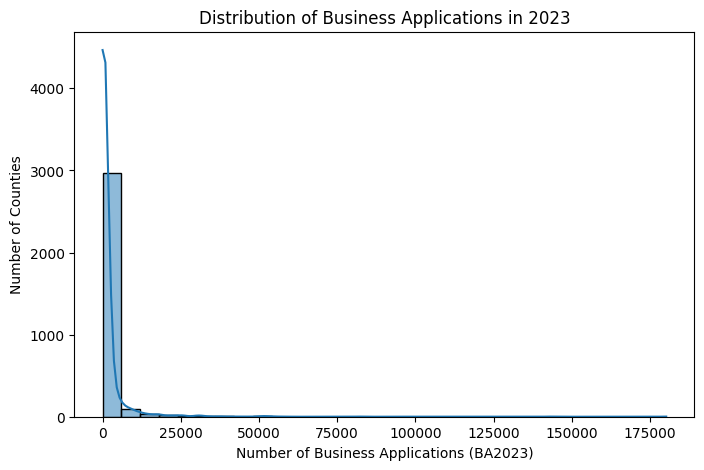

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=business_filtered, x='BA2023', bins=30, kde=True)

plt.title('Distribution of Business Applications in 2023')
plt.xlabel('Number of Business Applications (BA2023)')
plt.ylabel('Number of Counties')
plt.show()

The graph shows a strongly right-skewed distribution. Most counties had a low number of business applications, while a few counties had extremely high values. These high values increase the mean (1,727) far above the median (268).

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='BA2023'>

Text(0.5, 1.0, 'Boxplot of Business Establishments in 2023')

Text(0.5, 0, 'Number of Business Establishments (BA2023)')

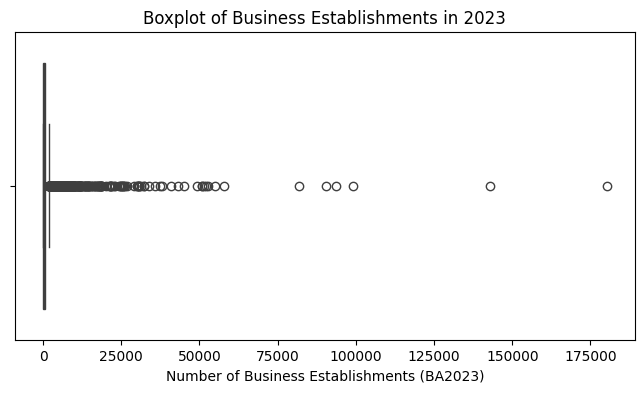

In [81]:
#Boxplot para identificar valores extremos
plt.figure(figsize=(8, 4))
sns.boxplot(data=business_filtered, x='BA2023')

plt.title('Boxplot of Business Establishments in 2023')
plt.xlabel('Number of Business Establishments (BA2023)')
plt.show()

The boxplot shows many high outliers. Most counties had a relatively low number of business applications, but a few counties had extremely high numbers—up to 180,178. This confirms that the distribution is strongly right-skewed.

In [82]:
business_filtered.sort_values(
    by='BA2023',
    ascending=False
)[['County Code', 'BA2023']].head(6)

,County Code,BA2023
207,06037,180178.0
374,12086,143025.0
2636,48201,99108.0
622,17031,93800.0
106,04013,90580.0
337,12011,81946.0


In [83]:
business.sort_values(
    by='BA2023',
    ascending=False
)[['County', 'BA2023']].head(6)

,County,BA2023
207,Los Angeles County,180178.0
374,Miami-Dade County,143025.0
2636,Harris County,99108.0
622,Cook County,93800.0
106,Maricopa County,90580.0
337,Broward County,81946.0


###c) Graphics for Industry

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Employment Location Quotient Relative to U.S.', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Employment Location Quotient')

Text(0.5, 0, 'Employment Location Quotient')

Text(0, 0.5, 'Number of Counties')

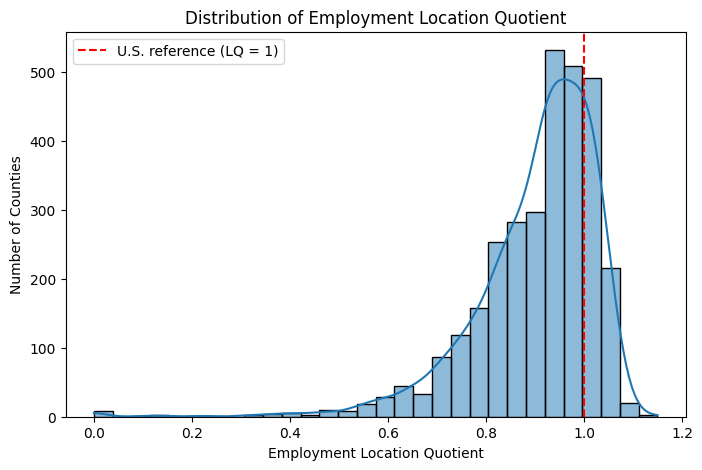

In [84]:
lq_column = 'Employment Location Quotient Relative to U.S.'

plt.figure(figsize=(8, 5))
sns.histplot(data=priv_filtered, x=lq_column, bins=30, kde=True)

# National reference value
plt.axvline(
    x=1,
    color='red',
    linestyle='--',
    label='U.S. reference (LQ = 1)'
)

plt.title('Distribution of Employment Location Quotient')
plt.xlabel('Employment Location Quotient')
plt.ylabel('Number of Counties')
plt.legend()
plt.show()

The histogram shows that most counties have an Employment Location Quotient between **0.80 and 1.05**. Most values are below the U.S. reference of **LQ = 1**, meaning most counties have a lower employment concentration than the national level. The distribution is **left-skewed** because a few counties have very low values.


In [85]:
lq_column = 'Employment Location Quotient Relative to U.S.'

# Six lowest values
priv_filtered.nsmallest(
    6, lq_column
)[['County Code', lq_column]]

,County Code,Employment Location Quotient Relative to U.S.
5765,09013,0.0
5783,09015,0.0
5837,10001,0.0
31391,32011,0.0
48034,48301,0.0
50489,50009,0.0


In [86]:
lq_column_check = 'Employment Location Quotient Relative to U.S.'

# Six lowest values
priv.nsmallest(
    6, lq_column_check
)[['County', lq_column_check]]

,County,Employment Location Quotient Relative to U.S.
5765,"Tolland County, Connecticut",0.0
5783,"Windham County, Connecticut",0.0
5837,"Kent County, Delaware",0.0
31391,"Eureka County, Nevada",0.0
48034,"Loving County, Texas",0.0
50489,"Essex County, Vermont",0.0


In [87]:
# Six highest values
priv_filtered.nlargest(
    6, lq_column
)[['County Code', lq_column]]

,County Code,Employment Location Quotient Relative to U.S.
31527,32029,1.15
10386,16023,1.14
4611,08014,1.12
13189,18051,1.10
52548,51595,1.10
13086,18039,1.09


In [88]:
# Six highest values
priv.nlargest(
    6, lq_column_check
)[['County', lq_column_check]]

,County,Employment Location Quotient Relative to U.S.
31527,"Storey County, Nevada",1.15
10386,"Butte County, Idaho",1.14
4611,"Broomfield County, Colorado",1.12
13189,"Gibson County, Indiana",1.10
52548,"Emporia City, Virginia",1.10
13086,"Elkhart County, Indiana",1.09


<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Employment Location Quotient Relative to U.S.'>

Text(0.5, 1.0, 'Boxplot of Employment Location Quotient')

Text(0.5, 0, 'Employment Location Quotient')

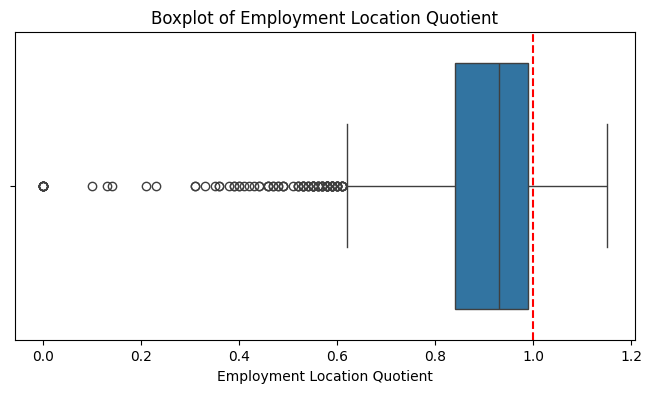

In [89]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=priv_filtered, x=lq_column)

plt.axvline(x=1, color='red', linestyle='--')

plt.title('Boxplot of Employment Location Quotient')
plt.xlabel('Employment Location Quotient')
plt.show()

The histogram shows how the counties are distributed. The boxplot shows the median, dispersion, and possible outliers. In the Location Quotient chart, the red line represents the national level (LQ = 1).

The boxplot shows that most counties have an LQ between **0.84 and 0.99**, with a median of **0.93**. Most counties are below the U.S. reference level (**LQ = 1**). The many low outliers indicate counties with employment concentrations much lower than the national level, while only a smaller group is above 1. Values near **0** should be checked for possible missing or unusual data.


#Conclusions
Overall, business applications are concentrated in a few counties, while most counties have employment levels below the U.S. reference.


#Limitation and Next Steps

* The study does not examine regional differences or industry clusters.
* It uses a single period instead of panel data from 2003–2023.
* It does not analyze the effects of the 2008 financial crisis or COVID-19.
* Demographic and educational control variables are missing.
* Taxes, universities, and business support programs are not included.
* It does not distinguish among industries or types of entrepreneurship.
* It measures business formation but not business closures or survival.
* It focuses mainly on economic factors, limiting the analysis of resilience.

##Some issues to solve>

*  Annual Average Establishment Count	object
*  Annual Average Employment	object
*  Annual Total Wages	object
*  Annual Average Weekly Wage	object
*  Annual Average Pay	object
businesspriv.dtypes

##Merge
Merge both datasets by County Code and calculate the Business Application Rate by dividing BA2023 from Dataset 1 by Private Establishments from Dataset 2.

